# UAS NLP — Analisis Sentimen Komparatif Gojek vs Grab
## Modeling: GRU vs Fine-Tuning IndoBERT

## 1. Setup & Konfigurasi

Install dependency yang diperlukan.


In [ ]:
# Jalankan cell ini jika library belum terpasang di environment 
!pip install transformers datasets accelerate --quiet
!pip install google-colab --quiet
!pip install -U transformers accelerate evaluate scikit-learn datasets --quiet

In [22]:
# ============================================================
# Import library utama
# ============================================================
import os
import re
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)

# Hugging Face 'datasets' digunakan agar kompatibel dengan Trainer API
from datasets import Dataset as HFDataset

# ============================================================
# Reproducibility
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")


Menggunakan device: cuda


In [ ]:
# ============================================================
# Konfigurasi path proyek
# ============================================================

BASE_DIR = ".." 

DATA_DIR = os.path.join(BASE_DIR, "data", "bersih")
GOJEK_PATH = "/content/drive/MyDrive/NLP_UAS/data/bersih/gojek_review_bersih.csv"
GRAB_PATH  = "/content/drive/MyDrive/NLP_UAS/data/bersih/grab_review_bersih.csv"

MODEL_OUT_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR   = os.path.join(BASE_DIR, "results")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEXT_COL  = "clean_content"
LABEL_COL = "sentimen"

df_gojek = pd.read_csv(GOJEK_PATH)
df_grab  = pd.read_csv(GRAB_PATH)

# Menampilkan data
df_gojek[[TEXT_COL, LABEL_COL]].head()
df_grab[[TEXT_COL, LABEL_COL]].head()


,clean_content,sentimen
0,NaN,netral
1,oke gass,positif
2,aplikasi andalan pergi pergi drivernya cepat b...,positif
3,good,positif
4,kesini ga ngotak tarifnya ambil potongan driver,negatif


## 2. Data Loading & Preparation

Strategi yang digunakan:
- Kedua dataset (Gojek & Grab) **digabung** untuk proses training utama, sehingga model belajar
  representasi sentimen bahasa Indonesia yang lebih general dan robust.
- Kolom `brand` ditambahkan sebagai penanda asal data (Gojek/Grab), sehingga saat evaluasi
  di test set kita tetap bisa **memecah hasil evaluasi per brand** — ini membuat perbandingan
  performa "Gojek vs Grab" tetap adil dan terukur, sekaligus model tetap satu model yang konsisten
  untuk dibandingkan (GRU vs IndoBERT) secara head-to-head.
- Split dilakukan dengan **stratifikasi gabungan** (label sentimen + brand) agar proporsi
  kelas & brand di Train/Val/Test seimbang.


In [24]:
# ============================================================
# 2.1 Load dataset bersih
# ============================================================
df_gojek = pd.read_csv(GOJEK_PATH)
df_grab  = pd.read_csv(GRAB_PATH)

df_gojek["brand"] = "Gojek"
df_grab["brand"]  = "Grab"

print("Jumlah data Gojek:", len(df_gojek))
print("Jumlah data Grab :", len(df_grab))

df_gojek[[TEXT_COL, LABEL_COL]].head()


Jumlah data Gojek: 10000
Jumlah data Grab : 10000


,clean_content,sentimen
0,ga bertahun pakai dibilang pelanggaran promo m...,negatif
1,kesini parah lintah darat disaat kebutuhan per...,positif
2,kelas king,netral
3,ramah,positif
4,memuaskan,positif


In [ ]:
# ============================================================
# 2.2 Gabungkan dataset & pembersihan dasar 
# ============================================================
df_all = pd.concat([df_gojek, df_grab], ignore_index=True)

# Pastikan tidak ada nilai kosong / NaN di kolom teks & label
df_all = df_all.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
df_all[TEXT_COL] = df_all[TEXT_COL].astype(str)

# Normalisasi nama label (jaga-jaga jika ada inkonsistensi kapitalisasi/whitespace)
df_all[LABEL_COL] = df_all[LABEL_COL].astype(str).str.strip().str.capitalize()

print("Total data gabungan:", len(df_all))
print("\nDistribusi label:")
print(df_all[LABEL_COL].value_counts())
print("\nDistribusi brand:")
print(df_all["brand"].value_counts())


Total data gabungan: 18740

Distribusi label:
sentimen
Positif    10532
Netral      4179
Negatif     4029
Name: count, dtype: int64

Distribusi brand:
brand
Gojek    9473
Grab     9267
Name: count, dtype: int64


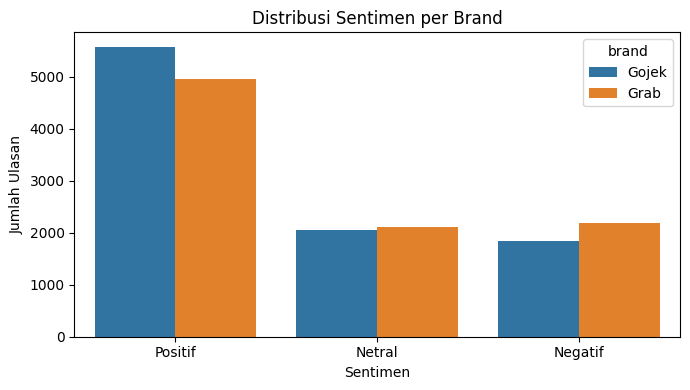

In [ ]:
# ============================================================
# 2.3 Visualisasi distribusi label per brand
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_all, x=LABEL_COL, hue="brand", order=["Positif", "Netral", "Negatif"], ax=ax)
ax.set_title("Distribusi Sentimen per Brand")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah Ulasan")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 2.4 Label Encoding
# ============================================================
# Encode label string (Positif/Netral/Negatif) menjadi integer
label_encoder = LabelEncoder()
df_all["label_id"] = label_encoder.fit_transform(df_all[LABEL_COL])

NUM_CLASSES = df_all["label_id"].nunique()
ID2LABEL = {i: lbl for i, lbl in enumerate(label_encoder.classes_)}
LABEL2ID = {lbl: i for i, lbl in ID2LABEL.items()}

print("Mapping label:", ID2LABEL)
print("Jumlah kelas :", NUM_CLASSES)


Mapping label: {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
Jumlah kelas : 3


In [ ]:
# ============================================================
# 2.5 Train / Validation / Test Split
# ============================================================
# Stratifikasi gabungan label + brand agar proporsi tetap konsisten di setiap split.
df_all["strat_key"] = df_all[LABEL_COL] + "_" + df_all["brand"]

# Split awal: 80% train, 20% temp (untuk val+test)
df_train, df_temp = train_test_split(
    df_all, test_size=0.20, random_state=SEED, stratify=df_all["strat_key"]
)
# Split temp -> 50% val, 50% test (=> 10% val, 10% test dari total data)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["strat_key"]
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("\nDistribusi brand di Test set:")
print(df_test["brand"].value_counts())


Train: 14992 | Val: 1874 | Test: 1874

Distribusi brand di Test set:
brand
Gojek    948
Grab     926
Name: count, dtype: int64


## 3. Model 1 — GRU (Gated Recurrent Unit)

Model GRU dibangun dari nol menggunakan PyTorch dengan struktur:
`Embedding -> GRU (bidirectional, multi-layer) -> Dropout -> Fully Connected -> Softmax`

Tahapan:
1. Build vocabulary sederhana dari data training (tokenisasi whitespace, karena teks sudah
   melalui proses cleaning di `processing.ipynb`).
2. Konversi teks menjadi sequence of token-ids, padding/truncation ke panjang seragam.
3. Definisikan `Dataset` & `DataLoader` PyTorch.
4. Definisikan arsitektur `GRUClassifier`.
5. Training loop manual + evaluasi.


In [29]:
# ============================================================
# 3.1 Tokenisasi & Vocabulary Building (khusus untuk GRU)
# ============================================================
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
MAX_LEN_GRU = 64  # panjang sequence maksimum, sesuaikan dengan distribusi panjang ulasan

def simple_tokenize(text):
    """Tokenisasi sederhana berbasis whitespace (teks sudah bersih dari processing.ipynb)."""
    return text.lower().split()

def build_vocab(texts, min_freq=2):
    from collections import Counter
    counter = Counter()
    for t in texts:
        counter.update(simple_tokenize(t))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Vocabulary dibangun HANYA dari data training, agar tidak terjadi data leakage
vocab = build_vocab(df_train[TEXT_COL].tolist(), min_freq=2)
VOCAB_SIZE = len(vocab)
print("Ukuran vocabulary:", VOCAB_SIZE)

def encode_text(text, vocab, max_len=MAX_LEN_GRU):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]
    ids = ids[:max_len]
    ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


Ukuran vocabulary: 4581


In [30]:
# ============================================================
# 3.2 Custom Dataset & DataLoader untuk GRU
# ============================================================
class ReviewDatasetGRU(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN_GRU):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], self.vocab, self.max_len)
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds_gru = ReviewDatasetGRU(df_train[TEXT_COL].tolist(), df_train["label_id"].tolist(), vocab)
val_ds_gru   = ReviewDatasetGRU(df_val[TEXT_COL].tolist(),   df_val["label_id"].tolist(),   vocab)
test_ds_gru  = ReviewDatasetGRU(df_test[TEXT_COL].tolist(),  df_test["label_id"].tolist(),  vocab)

BATCH_SIZE_GRU = 32
train_loader_gru = DataLoader(train_ds_gru, batch_size=BATCH_SIZE_GRU, shuffle=True)
val_loader_gru   = DataLoader(val_ds_gru,   batch_size=BATCH_SIZE_GRU, shuffle=False)
test_loader_gru  = DataLoader(test_ds_gru,  batch_size=BATCH_SIZE_GRU, shuffle=False)


In [31]:
# ============================================================
# 3.3 Arsitektur Model GRU
# ============================================================
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_classes=3, num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional -> hidden_dim * 2
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)               # (batch, seq_len, embed_dim)
        gru_out, hidden = self.gru(embedded)                # hidden: (num_layers*2, batch, hidden_dim)
        # Ambil hidden state terakhir dari arah forward & backward, lalu gabungkan
        last_forward  = hidden[-2, :, :]
        last_backward = hidden[-1, :, :]
        combined = torch.cat([last_forward, last_backward], dim=1)  # (batch, hidden_dim*2)
        out = self.dropout(combined)
        logits = self.fc(out)
        return logits

gru_model = GRUClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES,
    num_layers=2,
    dropout=0.3,
    pad_idx=vocab[PAD_TOKEN]
).to(DEVICE)

print(gru_model)
total_params = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


GRUClassifier(
  (embedding): Embedding(4581, 128, padding_idx=0)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total trainable parameters: 1,081,731


In [32]:
# ============================================================
# 3.4 Training Loop GRU
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # cegah exploding gradient
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate_gru(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)
            total_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_preds, all_labels


In [33]:
# ============================================================
# 3.5 Eksekusi Training GRU
# ============================================================
N_EPOCHS_GRU = 10
LR_GRU = 1e-3

criterion_gru = nn.CrossEntropyLoss()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=LR_GRU)

history_gru = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_f1 = 0.0
best_model_path = os.path.join(MODEL_OUT_DIR, "gru_best_model.pt")

for epoch in range(1, N_EPOCHS_GRU + 1):
    train_loss, train_acc = train_one_epoch(gru_model, train_loader_gru, optimizer_gru, criterion_gru, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate_gru(gru_model, val_loader_gru, criterion_gru, DEVICE)

    history_gru["train_loss"].append(train_loss)
    history_gru["train_acc"].append(train_acc)
    history_gru["val_loss"].append(val_loss)
    history_gru["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{N_EPOCHS_GRU} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # Simpan model terbaik berdasarkan F1-score validasi (macro)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(gru_model.state_dict(), best_model_path)
        print(f"  -> Model terbaik disimpan (Val F1: {val_f1:.4f})")


Epoch 01/10 | Train Loss: 0.6480 Acc: 0.7277 | Val Loss: 0.5435 Acc: 0.7898 F1: 0.7564
  -> Model terbaik disimpan (Val F1: 0.7564)
Epoch 02/10 | Train Loss: 0.4901 Acc: 0.8168 | Val Loss: 0.5009 Acc: 0.7994 F1: 0.7595
  -> Model terbaik disimpan (Val F1: 0.7595)
Epoch 03/10 | Train Loss: 0.4102 Acc: 0.8494 | Val Loss: 0.4992 Acc: 0.8111 F1: 0.7799
  -> Model terbaik disimpan (Val F1: 0.7799)
Epoch 04/10 | Train Loss: 0.3393 Acc: 0.8811 | Val Loss: 0.5234 Acc: 0.8100 F1: 0.7753
Epoch 05/10 | Train Loss: 0.2684 Acc: 0.9112 | Val Loss: 0.5368 Acc: 0.8132 F1: 0.7788
Epoch 06/10 | Train Loss: 0.2135 Acc: 0.9327 | Val Loss: 0.6453 Acc: 0.8010 F1: 0.7603
Epoch 07/10 | Train Loss: 0.1694 Acc: 0.9463 | Val Loss: 0.7400 Acc: 0.7988 F1: 0.7582
Epoch 08/10 | Train Loss: 0.1433 Acc: 0.9568 | Val Loss: 0.8598 Acc: 0.8100 F1: 0.7743
Epoch 09/10 | Train Loss: 0.1261 Acc: 0.9638 | Val Loss: 0.9116 Acc: 0.7956 F1: 0.7525
Epoch 10/10 | Train Loss: 0.1162 Acc: 0.9668 | Val Loss: 0.9569 Acc: 0.8036 F1: 0.

In [34]:
# ============================================================
# 3.6 Evaluasi Final GRU pada Test Set
# ============================================================
# Load model terbaik (berdasarkan validation F1) sebelum evaluasi final
gru_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss_gru, test_acc_gru, test_f1_gru, preds_gru, labels_gru = evaluate_gru(
    gru_model, test_loader_gru, criterion_gru, DEVICE
)

precision_gru = precision_score(labels_gru, preds_gru, average="macro")
recall_gru = recall_score(labels_gru, preds_gru, average="macro")

print("=== Hasil Evaluasi GRU pada Test Set ===")
print(f"Accuracy : {test_acc_gru:.4f}")
print(f"F1 (macro): {test_f1_gru:.4f}")
print(f"Precision : {precision_gru:.4f}")
print(f"Recall    : {recall_gru:.4f}")
print()
print(classification_report(labels_gru, preds_gru, target_names=label_encoder.classes_))


=== Hasil Evaluasi GRU pada Test Set ===
Accuracy : 0.7978
F1 (macro): 0.7652
Precision : 0.7629
Recall    : 0.7770

              precision    recall  f1-score   support

     Negatif       0.65      0.83      0.73       403
      Netral       0.74      0.66      0.70       418
     Positif       0.90      0.84      0.87      1053

    accuracy                           0.80      1874
   macro avg       0.76      0.78      0.77      1874
weighted avg       0.81      0.80      0.80      1874



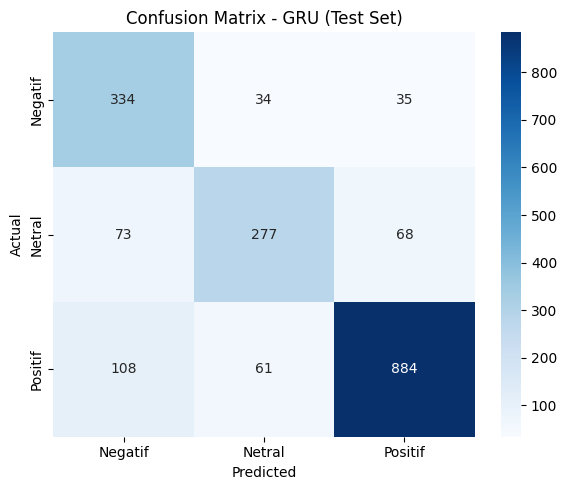

In [35]:
# ============================================================
# 3.7 Confusion Matrix - GRU
# ============================================================
cm_gru = confusion_matrix(labels_gru, preds_gru)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - GRU (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [36]:
# ============================================================
# 3.8 Evaluasi GRU per Brand (Gojek vs Grab) di Test Set
# ============================================================
def evaluate_per_brand(df_test, preds, label_col="brand"):
    """Memecah hasil prediksi menjadi metrik per brand untuk perbandingan adil Gojek vs Grab."""
    results = {}
    df_eval = df_test.copy()
    df_eval["pred"] = preds
    for brand in df_eval["brand"].unique():
        subset = df_eval[df_eval["brand"] == brand]
        acc = accuracy_score(subset["label_id"], subset["pred"])
        f1 = f1_score(subset["label_id"], subset["pred"], average="macro")
        results[brand] = {"accuracy": acc, "f1_macro": f1, "n_samples": len(subset)}
    return results

gru_per_brand = evaluate_per_brand(df_test, preds_gru)
print("=== Hasil GRU per Brand ===")
for brand, metrics in gru_per_brand.items():
    print(f"{brand}: Accuracy={metrics['accuracy']:.4f} | F1={metrics['f1_macro']:.4f} | N={metrics['n_samples']}")


=== Hasil GRU per Brand ===
Grab: Accuracy=0.7905 | F1=0.7613 | N=926
Gojek: Accuracy=0.8049 | F1=0.7690 | N=948


## 4. Model 2 — Fine-Tuning IndoBERT (Transformer)

Menggunakan model pre-trained `indobenchmark/indobert-base-p2` dari Hugging Face, di-fine-tune
untuk task klasifikasi sentimen 3 kelas menggunakan `Trainer` API.


In [37]:
# ============================================================
# 4.1 Tokenisasi dengan AutoTokenizer (IndoBERT)
# ============================================================
MODEL_CHECKPOINT = "indobenchmark/indobert-base-p2"
MAX_LEN_BERT = 64  # sesuaikan dengan panjang ulasan rata-rata; cek distribusi panjang jika perlu

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN_BERT
    )

# Konversi pandas DataFrame -> HuggingFace Dataset
hf_train = HFDataset.from_pandas(df_train[[TEXT_COL, "label_id", "brand"]].rename(columns={"label_id": "label"}))
hf_val   = HFDataset.from_pandas(df_val[[TEXT_COL, "label_id", "brand"]].rename(columns={"label_id": "label"}))
hf_test  = HFDataset.from_pandas(df_test[[TEXT_COL, "label_id", "brand"]].rename(columns={"label_id": "label"}))

hf_train = hf_train.map(tokenize_function, batched=True)
hf_val   = hf_val.map(tokenize_function, batched=True)
hf_test  = hf_test.map(tokenize_function, batched=True)

# Set format ke torch tensors, kolom 'brand' tetap disimpan untuk evaluasi per-brand nanti
hf_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
hf_val.set_format(type="torch",   columns=["input_ids", "attention_mask", "label"])
# Untuk test set, kita simpan 'brand' di luar (sebagai list python) agar tidak ikut jadi tensor
test_brands = hf_test["brand"]
hf_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(hf_train)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Map:   0%|          | 0/14992 [00:00<?, ? examples/s]

Map:   0%|          | 0/1874 [00:00<?, ? examples/s]

Map:   0%|          | 0/1874 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_content', 'label', 'brand', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14992
})


In [38]:
# ============================================================
# 4.2 Load Pre-trained Model untuk Sequence Classification
# ============================================================
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
# ============================================================
# 4.3 Fungsi Metrik untuk Trainer
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }


In [40]:
# ============================================================
# 4.4 Training Arguments & Trainer
# ============================================================
training_args = TrainingArguments(
    output_dir=os.path.join(MODEL_OUT_DIR, "indobert_checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir=os.path.join(RESULTS_DIR, "indobert_logs"),
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",  # nonaktifkan integrasi eksternal (wandb, dll)
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# ============================================================
# 4.5 Eksekusi Fine-Tuning IndoBERT
# ============================================================
train_result = trainer.train()

# Simpan riwayat training (loss & metrik per epoch) untuk visualisasi
log_history_bert = trainer.state.log_history


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.433705,0.402599,0.853255,0.819047,0.842761,0.812910
2,0.307433,0.417568,0.866062,0.835884,0.847106,0.827489
3,0.178717,0.509172,0.864995,0.836701,0.842785,0.834604
4,0.178722,0.602422,0.862860,0.832621,0.840887,0.827300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
# ============================================================
# 4.6 Evaluasi Final IndoBERT pada Test Set
# ============================================================
test_metrics_bert = trainer.evaluate(hf_test)
print("=== Hasil Evaluasi IndoBERT pada Test Set ===")
for k, v in test_metrics_bert.items():
    print(f"{k}: {v}")


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.178722,0.513050,4,0.863394,0.834151,0.843752,0.829658


=== Hasil Evaluasi IndoBERT pada Test Set ===
eval_loss: 0.5130504965782166
eval_accuracy: 0.8633938100320171
eval_f1_macro: 0.8341510903426791
eval_precision_macro: 0.8437517617089801
eval_recall_macro: 0.8296583976644344


              precision    recall  f1-score   support

     Negatif       0.78      0.85      0.82       403
      Netral       0.85      0.71      0.77       418
     Positif       0.90      0.93      0.91      1053

    accuracy                           0.86      1874
   macro avg       0.84      0.83      0.83      1874
weighted avg       0.86      0.86      0.86      1874



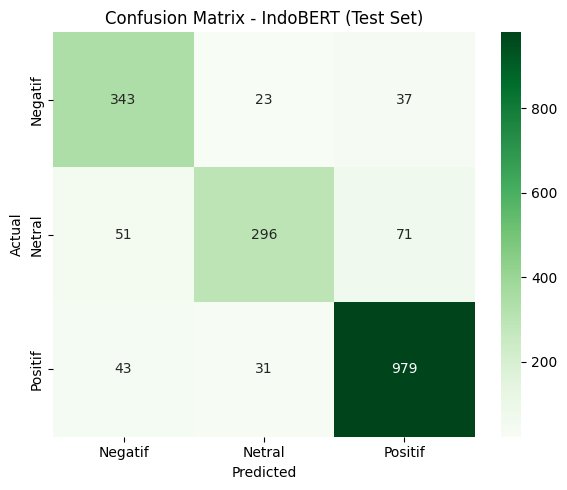

In [43]:
# ============================================================
# 4.7 Prediksi & Confusion Matrix - IndoBERT
# ============================================================
pred_output = trainer.predict(hf_test)
preds_bert = np.argmax(pred_output.predictions, axis=1)
labels_bert = pred_output.label_ids

print(classification_report(labels_bert, preds_bert, target_names=label_encoder.classes_))

cm_bert = confusion_matrix(labels_bert, preds_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - IndoBERT (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [46]:
print("hf_test", hf_test)

hf_test Dataset({
    features: ['clean_content', 'label', 'brand', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1874
})


In [49]:
# ============================================================
# 4.8 Evaluasi IndoBERT per Brand (Gojek vs Grab)
# ============================================================
df_test_bert_eval = hf_test.to_pandas()
        
df_test_bert_eval["pred"] = list(preds_bert)

bert_per_brand = {}
for brand in df_test_bert_eval["brand"].unique():
    subset = df_test_bert_eval[df_test_bert_eval["brand"] == brand]
    acc = accuracy_score(subset["label"], subset["pred"])
    f1 = f1_score(subset["label"], subset["pred"], average="macro")
    bert_per_brand[brand] = {"accuracy": acc, "f1_macro": f1, "n_samples": len(subset)}

print("=== Hasil IndoBERT per Brand ===")
for brand, metrics in bert_per_brand.items():
    print(f"{brand}: Accuracy={metrics['accuracy']:.4f} | F1={metrics['f1_macro']:.4f} | N={metrics['n_samples']}")


=== Hasil IndoBERT per Brand ===
Grab: Accuracy=0.8607 | F1=0.8345 | N=926
Gojek: Accuracy=0.8660 | F1=0.8341 | N=948


## 5. Analisis Perbandingan & Visualisasi

Membandingkan performa GRU vs IndoBERT secara keseluruhan, dan juga dipecah per brand
(Gojek vs Grab) untuk melihat apakah ada perbedaan kesulitan model dalam menangani ulasan
masing-masing aplikasi.


In [50]:
# ============================================================
# 5.1 Tabel Ringkasan Perbandingan Keseluruhan (Test Set)
# ============================================================
summary_df = pd.DataFrame([
    {
        "Model": "GRU",
        "Accuracy": test_acc_gru,
        "F1_macro": test_f1_gru,
        "Precision_macro": precision_gru,
        "Recall_macro": recall_gru,
    },
    {
        "Model": "IndoBERT",
        "Accuracy": test_metrics_bert["eval_accuracy"],
        "F1_macro": test_metrics_bert["eval_f1_macro"],
        "Precision_macro": test_metrics_bert["eval_precision_macro"],
        "Recall_macro": test_metrics_bert["eval_recall_macro"],
    },
])
summary_df = summary_df.round(4)
summary_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison_summary.csv"), index=False)
summary_df


,Model,Accuracy,F1_macro,Precision_macro,Recall_macro
0,GRU,0.7978,0.7652,0.7629,0.7770
1,IndoBERT,0.8634,0.8342,0.8438,0.8297


/tmp/ipykernel_14784/121586184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_14784/121586184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y=metric, ax=ax, palette="viridis")


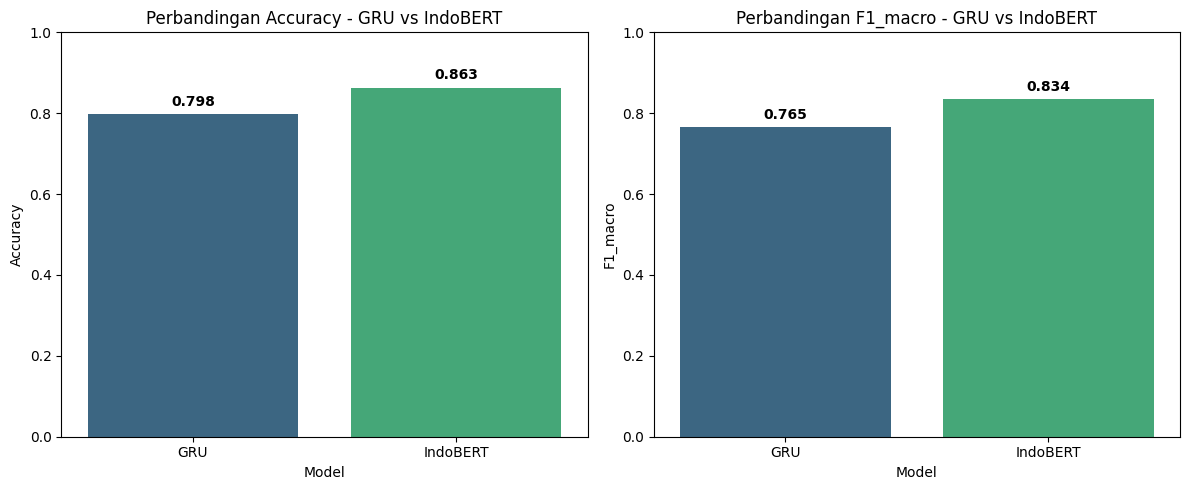

In [51]:
# ============================================================
# 5.2 Visualisasi Bar Chart: Accuracy & F1 keseluruhan (GRU vs IndoBERT)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_to_plot = ["Accuracy", "F1_macro"]
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=summary_df, x="Model", y=metric, ax=ax, palette="viridis")
    ax.set_title(f"Perbandingan {metric} - GRU vs IndoBERT")
    ax.set_ylim(0, 1)
    for i, val in enumerate(summary_df[metric]):
        ax.text(i, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "comparison_overall.png"), dpi=150)
plt.show()


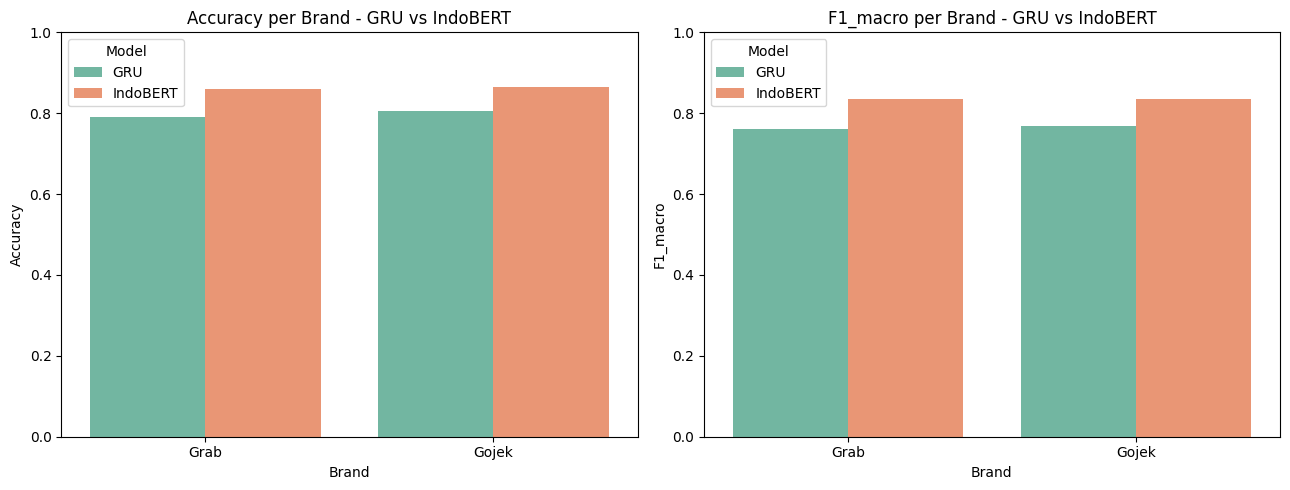

,Model,Brand,Accuracy,F1_macro
0,GRU,Grab,0.7905,0.7613
1,GRU,Gojek,0.8049,0.7690
2,IndoBERT,Grab,0.8607,0.8345
3,IndoBERT,Gojek,0.8660,0.8341


In [52]:
# ============================================================
# 5.3 Visualisasi Perbandingan per Brand (Gojek vs Grab) — GRU vs IndoBERT
# ============================================================
per_brand_records = []
for brand, m in gru_per_brand.items():
    per_brand_records.append({"Model": "GRU", "Brand": brand, "Accuracy": m["accuracy"], "F1_macro": m["f1_macro"]})
for brand, m in bert_per_brand.items():
    per_brand_records.append({"Model": "IndoBERT", "Brand": brand, "Accuracy": m["accuracy"], "F1_macro": m["f1_macro"]})

per_brand_df = pd.DataFrame(per_brand_records).round(4)
per_brand_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison_per_brand.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["Accuracy", "F1_macro"]):
    sns.barplot(data=per_brand_df, x="Brand", y=metric, hue="Model", ax=ax, palette="Set2")
    ax.set_title(f"{metric} per Brand - GRU vs IndoBERT")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "comparison_per_brand.png"), dpi=150)
plt.show()

per_brand_df


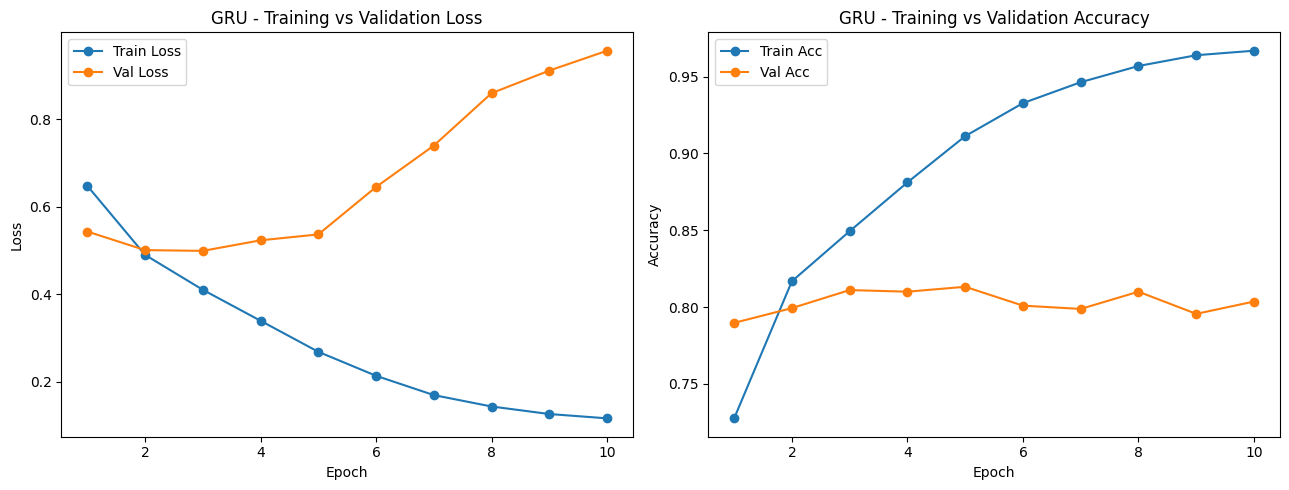

In [53]:
# ============================================================
# 5.4 Visualisasi Learning Curve (Loss) - GRU
# ============================================================
epochs_range = range(1, len(history_gru["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history_gru["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history_gru["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("GRU - Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history_gru["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history_gru["val_acc"], marker="o", label="Val Acc")
axes[1].set_title("GRU - Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "gru_learning_curve.png"), dpi=150)
plt.show()


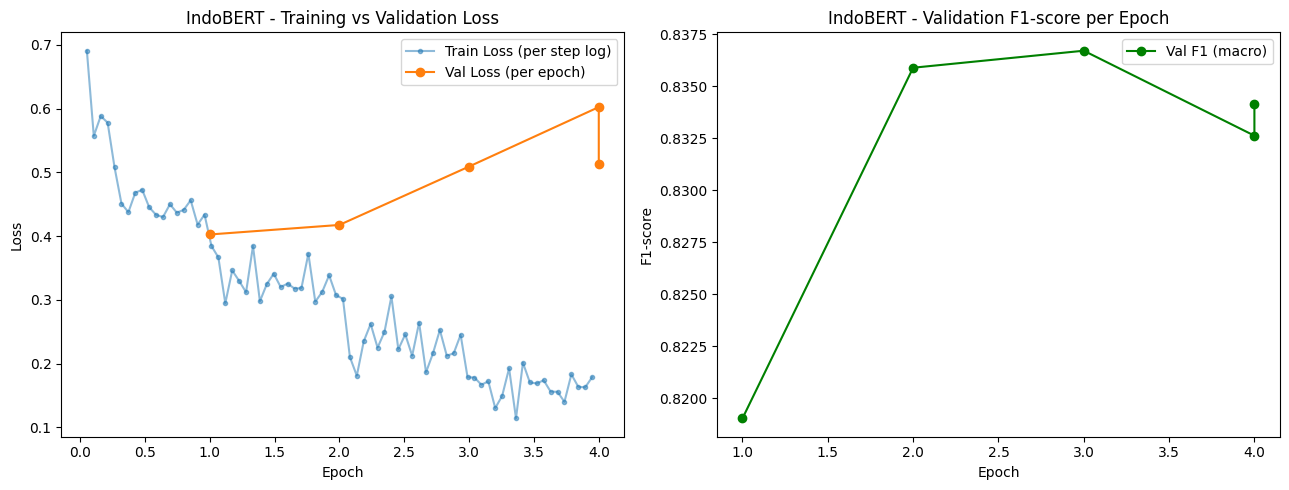

In [54]:
# ============================================================
# 5.5 Visualisasi Learning Curve (Loss & F1) - IndoBERT
# ============================================================
# Ekstrak log eval & train dari trainer.state.log_history
train_logs = [l for l in log_history_bert if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history_bert if "eval_loss" in l]

train_epochs = [l["epoch"] for l in train_logs]
train_losses = [l["loss"] for l in train_logs]

eval_epochs = [l["epoch"] for l in eval_logs]
eval_losses = [l["eval_loss"] for l in eval_logs]
eval_f1s    = [l["eval_f1_macro"] for l in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_epochs, train_losses, marker=".", alpha=0.5, label="Train Loss (per step log)")
axes[0].plot(eval_epochs, eval_losses, marker="o", label="Val Loss (per epoch)")
axes[0].set_title("IndoBERT - Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(eval_epochs, eval_f1s, marker="o", color="green", label="Val F1 (macro)")
axes[1].set_title("IndoBERT - Validation F1-score per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "indobert_learning_curve.png"), dpi=150)
plt.show()


## 6. Deployment Preparation — Push ke Hugging Face Hub

Setelah IndoBERT selesai di-fine-tune, langkah selanjutnya adalah:
1. Menyimpan model + tokenizer ke lokal (sudah dilakukan otomatis di akhir Section 4 lewat
   `trainer.save_model()`).
2. Login ke Hugging Face Hub, lalu push model+tokenizer ke repo Model Hub agar bisa
   dipakai ulang dari mana saja (`AutoModel.from_pretrained("username/repo-name")`).
3. Membuat aplikasi web interaktif (`app.py` berbasis Gradio) untuk di-deploy ke
   Hugging Face Spaces, sehingga model bisa didemokan secara publik.


In [ ]:
# ============================================================
# 6.1 Install & Login ke Hugging Face Hub
# ============================================================
# !pip install huggingface_hub --quiet

from huggingface_hub import login, HfApi, create_repo
import getpass

# Login ke Hugging Face Hub
hf_token = getpass.getpass("Masukkan Hugging Face Access Token (write permission): ")
login(token=hf_token)


In [57]:
# ============================================================
# 6.2 Konfigurasi Repo Tujuan di Hugging Face Hub
# ============================================================
# Ganti dengan username Hugging Face Masing-masing
HF_USERNAME = "mijaan"
HF_REPO_NAME = "indobert-sentimen-gojek-grab"
HF_REPO_ID = f"{HF_USERNAME}/{HF_REPO_NAME}"

# Buat repo jika belum ada (private=False supaya publik, sesuaikan kebutuhan)
create_repo(repo_id=HF_REPO_ID, exist_ok=True, private=False)
print("Repo siap:", f"https://huggingface.co/{HF_REPO_ID}")


Repo siap: https://huggingface.co/mijaan/indobert-sentimen-gojek-grab


In [58]:
# ============================================================
# 6.3 Push Model & Tokenizer IndoBERT ke Hugging Face Hub
# ============================================================
# bert_save_dir adalah folder lokal hasil trainer.save_model() di Section 4
# (berisi config.json, model.safetensors/pytorch_model.bin, tokenizer files, dll)

bert_model.push_to_hub(HF_REPO_ID, commit_message="Upload fine-tuned IndoBERT sentiment model (Gojek vs Grab)")
tokenizer.push_to_hub(HF_REPO_ID, commit_message="Upload tokenizer IndoBERT")

print(f"Model & tokenizer berhasil diupload ke: https://huggingface.co/{HF_REPO_ID}")
print("Cara load kembali dari mana saja:")
print(f'  AutoModelForSequenceClassification.from_pretrained("{HF_REPO_ID}")')
print(f'  AutoTokenizer.from_pretrained("{HF_REPO_ID}")')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mkcfpk1/model.safetensors:   0%|          |  552kB /  498MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Model & tokenizer berhasil diupload ke: https://huggingface.co/mijaan/indobert-sentimen-gojek-grab
Cara load kembali dari mana saja:
  AutoModelForSequenceClassification.from_pretrained("mijaan/indobert-sentimen-gojek-grab")
  AutoTokenizer.from_pretrained("mijaan/indobert-sentimen-gojek-grab")


In [ ]:
# ============================================================
# 6.4 Upload mapping label & metadata tambahan
# ============================================================
# Simpan mapping label sebagai file terpisah agar mudah dipakai ulang oleh app.py / pengguna lain
import json as _json

bert_save_dir = "./results"

label_map_path = os.path.join(bert_save_dir, "label_mapping.json")
with open(label_map_path, "w", encoding="utf-8") as f:
    _json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID}, f, ensure_ascii=False, indent=2)

api = HfApi()
api.upload_file(
    path_or_fileobj=label_map_path,
    path_in_repo="label_mapping.json",
    repo_id=HF_REPO_ID,
)
print("label_mapping.json berhasil diupload ke repo.")


label_mapping.json berhasil diupload ke repo.


In [80]:
# ============================================================
# 6.5 Generate file app.py untuk Hugging Face Spaces (Gradio)
# ============================================================

DEPLOY_DIR = os.path.join(BASE_DIR, "deployment")
os.makedirs(DEPLOY_DIR, exist_ok=True)

app_py_code = f"""
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ============================================================
# Load model & tokenizer langsung dari Hugging Face Hub
# (ganti REPO_ID jika kamu upload ke repo lain)
# ============================================================
REPO_ID = "{HF_REPO_ID}"

tokenizer = AutoTokenizer.from_pretrained(REPO_ID)
model = AutoModelForSequenceClassification.from_pretrained(REPO_ID)
model.eval()

ID2LABEL = model.config.id2label  # otomatis terbawa dari config.json saat push_to_hub


def predict_sentiment(text):
    \"\"\"Prediksi sentimen dari satu ulasan teks (Gojek/Grab).\"\"\"
    if not text or not text.strip():
        return {{"Tidak ada input": 1.0}}

    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, padding=True, max_length=64
    )
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1).squeeze().tolist()

    result = {{ID2LABEL[i]: float(p) for i, p in enumerate(probs)}}
    return result


demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        label="Masukkan Ulasan (Gojek / Grab)",
        placeholder="Contoh: Aplikasinya sering error pas mau pesan driver...",
        lines=3,
    ),
    outputs=gr.Label(label="Hasil Prediksi Sentimen", num_top_classes=3),
    title="Analisis Sentimen Ulasan Gojek vs Grab (IndoBERT Fine-Tuned)",
    description=(
        "Model IndoBERT yang telah di-fine-tune untuk mengklasifikasikan sentimen "
        "ulasan pengguna Google Play Store (Positif / Netral / Negatif) untuk "
        "aplikasi Gojek dan Grab. Proyek UAS Mata Kuliah NLP."
    ),
    examples=[
        ["Aplikasi sangat membantu, driver cepat datang dan harga terjangkau"],
        ["Lumayan, tapi kadang susah dapat driver pas jam sibuk"],
        ["Aplikasinya lambat banget dan sering force close, sangat mengecewakan"],
        ["driver wangi, tapi suka ngebut"],
        ["fitur baru keren, tapi masih banyak bug"],
    ],
)

if __name__ == "__main__":
    demo.launch()
"""

app_py_path = os.path.join(DEPLOY_DIR, "app.py")
with open(app_py_path, "w", encoding="utf-8") as f:
    f.write(app_py_code)

print("app.py berhasil dibuat di:", app_py_path)


app.py berhasil dibuat di: ../deployment/app.py


In [81]:
# ============================================================
# 6.6 Generate requirements.txt untuk Hugging Face Spaces
# ============================================================
requirements_txt = """transformers>=4.40.0
torch>=2.0.0
accelerate
scikit-learn
"""

requirements_path = os.path.join(DEPLOY_DIR, "requirements.txt")
with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements_txt)

print("requirements.txt berhasil dibuat di:", requirements_path)

requirements.txt berhasil dibuat di: ../deployment/requirements.txt


In [82]:
# ============================================================
# 6.7 (Opsional) Push folder deployment sebagai Hugging Face Space
# ============================================================
# Buat repo baru bertipe 'space' 

HF_SPACE_NAME = "demo-sentimen-gojek-grab"
HF_SPACE_ID = f"{HF_USERNAME}/{HF_SPACE_NAME}"

create_repo(
    repo_id=HF_SPACE_ID,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True,
    private=False,
)

api.upload_folder(
    folder_path=DEPLOY_DIR,
    repo_id=HF_SPACE_ID,
    repo_type="space",
    commit_message="Deploy Gradio app untuk analisis sentimen Gojek vs Grab",
)

print(f"Space berhasil di-deploy! Akses di: https://huggingface.co/spaces/{HF_SPACE_ID}")


Space berhasil di-deploy! Akses di: https://huggingface.co/spaces/mijaan/demo-sentimen-gojek-grab


## 7. Kesimpulan

Cell di bawah menghasilkan ringkasan otomatis berbasis angka hasil eksperimen di atas.
**Catatan penting:** narasi kesimpulan akhir (interpretasi mendalam, kaitan dengan literatur,
implikasi bisnis, dsb.) sebaiknya tetap ditulis ulang secara manual oleh Anda setelah melihat
angka aktual yang dihasilkan — karena hasil model bisa berbeda tergantung run, jumlah epoch,
dan kualitas data — sehingga laporan UAS Anda mencerminkan analisis Anda sendiri.


In [83]:
# ============================================================
# 7.1 Ringkasan Otomatis & Penentuan Model Terbaik
# ============================================================
best_model_name = summary_df.loc[summary_df["F1_macro"].idxmax(), "Model"]
gap_f1 = abs(summary_df["F1_macro"].iloc[0] - summary_df["F1_macro"].iloc[1])

print("=" * 60)
print("RINGKASAN HASIL PERBANDINGAN MODEL")
print("=" * 60)
print(summary_df.to_string(index=False))
print("\nModel dengan F1-macro tertinggi pada Test Set:", best_model_name)
print(f"Selisih F1-macro antar model: {gap_f1:.4f}")
print()
print("Performa per brand:")
print(per_brand_df.to_string(index=False))
print("=" * 60)
print(
    "\nInterpretasi awal (silakan dikembangkan lebih lanjut dalam laporan):\n"
    f"- Berdasarkan metrik F1-macro pada test set, model {best_model_name} menunjukkan\n"
    "  performa yang lebih unggul dibandingkan model pembanding pada studi kasus ini.\n"
    "- IndoBERT umumnya diharapkan lebih unggul karena merupakan model pre-trained\n"
    "  berbasis Transformer yang sudah memahami representasi kontekstual bahasa Indonesia\n"
    "  (dilatih pada korpus besar), sehingga lebih baik dalam menangkap makna kalimat,\n"
    "  negasi, dan konteks dibanding GRU yang dilatih dari nol (from scratch) hanya\n"
    "  menggunakan data ulasan yang relatif terbatas.\n"
    "- Sebaliknya, GRU memiliki keunggulan dari sisi efisiensi komputasi: jumlah parameter\n"
    "  jauh lebih kecil, waktu training & inferensi lebih cepat, dan tidak memerlukan GPU\n"
    "  sebesar IndoBERT untuk deployment skala kecil.\n"
)


RINGKASAN HASIL PERBANDINGAN MODEL
   Model  Accuracy  F1_macro  Precision_macro  Recall_macro
     GRU    0.7978    0.7652           0.7629        0.7770
IndoBERT    0.8634    0.8342           0.8438        0.8297

Model dengan F1-macro tertinggi pada Test Set: IndoBERT
Selisih F1-macro antar model: 0.0690

Performa per brand:
   Model Brand  Accuracy  F1_macro
     GRU  Grab    0.7905    0.7613
     GRU Gojek    0.8049    0.7690
IndoBERT  Grab    0.8607    0.8345
IndoBERT Gojek    0.8660    0.8341

Interpretasi awal (silakan dikembangkan lebih lanjut dalam laporan):
- Berdasarkan metrik F1-macro pada test set, model IndoBERT menunjukkan
  performa yang lebih unggul dibandingkan model pembanding pada studi kasus ini.
- IndoBERT umumnya diharapkan lebih unggul karena merupakan model pre-trained
  berbasis Transformer yang sudah memahami representasi kontekstual bahasa Indonesia
  (dilatih pada korpus besar), sehingga lebih baik dalam menangkap makna kalimat,
  negasi, dan konteks diban

In [ ]:
# ============================================================
# 7.2 Simpan Model Final
# ============================================================
# Simpan model GRU beserta vocabulary-nya
torch.save({
    "model_state_dict": gru_model.state_dict(),
    "vocab": vocab,
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
    "max_len": MAX_LEN_GRU,
}, os.path.join(MODEL_OUT_DIR, "gru_final_artifact.pt"))

# Simpan model & tokenizer IndoBERT (format Hugging Face, siap dipakai via from_pretrained)
bert_save_dir = os.path.join(MODEL_OUT_DIR, "indobert_final")
trainer.save_model(bert_save_dir)
tokenizer.save_pretrained(bert_save_dir)

print("Model GRU disimpan di     :", os.path.join(MODEL_OUT_DIR, "gru_final_artifact.pt"))
print("Model IndoBERT disimpan di:", bert_save_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model GRU disimpan di     : ../models/gru_final_artifact.pt
Model IndoBERT disimpan di: ../models/indobert_final
